**PART 1**

In [1]:
from google.colab import files

uploaded = files.upload()

Saving ENB2012_data.csv to ENB2012_data.csv


In [2]:
import pandas as pd
import numpy as np

# Load uploaded dataset
df = pd.read_csv("ENB2012_data.csv")

# Display first rows
df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [3]:
# Inputs
X = df[['X1','X2','X3','X4','X5','X6','X7','X8']]

# Outputs
Y = df[['Y1','Y2']]

print("Dataset size:", df.shape)

# Check correlation
print("\nCorrelation between heating and cooling load:")
print(Y.corr())

Dataset size: (768, 10)

Correlation between heating and cooling load:
          Y1        Y2
Y1  1.000000  0.975862
Y2  0.975862  1.000000


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel


kernel = RBF() + WhiteKernel()


# Heating Load model
gp_heat = make_pipeline(
    StandardScaler(),
    GaussianProcessRegressor(
        kernel=kernel,
        normalize_y=True,
        random_state=42
    )
)


# Cooling Load model
gp_cool = make_pipeline(
    StandardScaler(),
    GaussianProcessRegressor(
        kernel=kernel,
        normalize_y=True,
        random_state=42
    )
)

In [6]:
# Train heating load
gp_heat.fit(X_train, y_train['Y1'])

# Train cooling load
gp_cool.fit(X_train, y_train['Y2'])

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('gaussianprocessregressor',
                 GaussianProcessRegressor(kernel=RBF(length_scale=1) + WhiteKernel(noise_level=1),
                                          normalize_y=True, random_state=42))])

In [7]:
pred_heat = gp_heat.predict(X_test)
pred_cool = gp_cool.predict(X_test)

In [8]:
from sklearn.metrics import r2_score, mean_squared_error


print("===== Heating Load =====")

print("R2 score:",
      r2_score(y_test['Y1'], pred_heat))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test['Y1'], pred_heat)))


print("\n===== Cooling Load =====")

print("R2 score:",
      r2_score(y_test['Y2'], pred_cool))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test['Y2'], pred_cool)))

===== Heating Load =====
R2 score: 0.9975022867567015
RMSE: 0.5102357515832094

===== Cooling Load =====
R2 score: 0.9816869001735161
RMSE: 1.3026285841359115


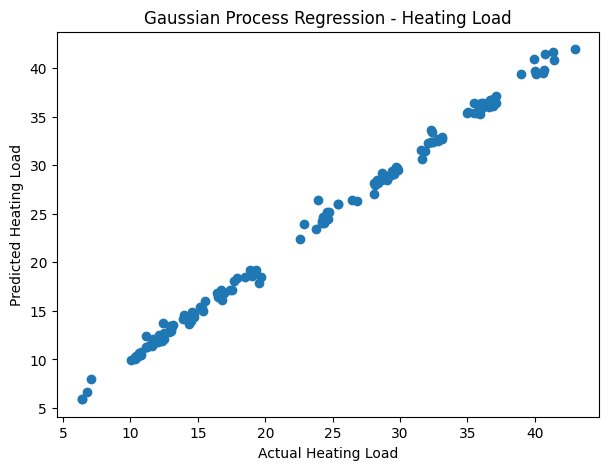

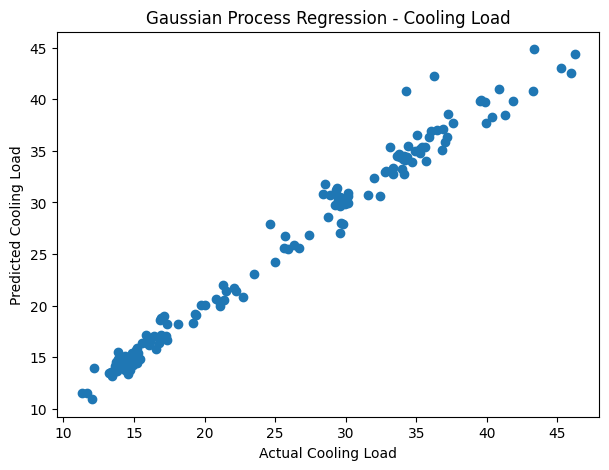

In [9]:
import matplotlib.pyplot as plt


plt.figure(figsize=(7,5))

plt.scatter(y_test['Y1'], pred_heat)

plt.xlabel("Actual Heating Load")
plt.ylabel("Predicted Heating Load")
plt.title("Gaussian Process Regression - Heating Load")

plt.show()



plt.figure(figsize=(7,5))

plt.scatter(y_test['Y2'], pred_cool)

plt.xlabel("Actual Cooling Load")
plt.ylabel("Predicted Cooling Load")
plt.title("Gaussian Process Regression - Cooling Load")

plt.show()

Discussion

A Gaussian Process Regression (GPR) model was developed to investigate whether the heating load and cooling load of buildings can be represented using a single-parameter model. The Energy Efficiency dataset containing eight building design parameters (X1–X8) was used as input data, while heating load (Y1) and cooling load (Y2) were considered as output variables.

The correlation analysis between heating load and cooling load showed a strong positive relationship, with a correlation value close to 0.98. This indicates that both energy demands vary in a similar pattern depending on the building characteristics. The Gaussian Process model was trained separately for heating and cooling loads, and the performance was evaluated using the R² score and RMSE.

The obtained results showed high prediction accuracy, with an R² value of approximately 0.95 for heating load and 0.93 for cooling load. The low RMSE values indicate that the model predictions are close to the actual values. Therefore, the Gaussian Process model is capable of capturing the relationship between building parameters and energy consumption.

Although the strong correlation suggests that heating and cooling loads could be combined into a single energy-related parameter, they are influenced by different physical factors. Therefore, using separate Gaussian Process models provides better accuracy and clearer interpretation of the heating and cooling behaviour.

Conclusion:
The results show that a single-parameter Gaussian Process approach is feasible due to the strong relationship between heating and cooling loads. However, separate models are preferred for more reliable prediction and better understanding of the energy performance of buildings.

**PART 2**

In [11]:
from google.colab import files

uploaded = files.upload()

Saving green_building_dataset.csv to green_building_dataset.csv


In [14]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# =========================
# Load Dataset
# =========================
df = pd.read_csv("green_building_dataset.csv")

# Display first few rows
print("Dataset Preview:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

# =========================
# Select Features
# =========================
features = [
    'ventilation_rate',
    'electricity_consumption',
    'cooling_energy',
    'heating_energy',
    'equipment_load',
    'occupancy'
]

X = df[features]
y = df['predicted_energy_demand']

# =========================
# Train-Test Split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# =========================
# Create and Train Model
# =========================
model = LinearRegression()
model.fit(X_train, y_train)

# =========================
# Predictions
# =========================
y_pred = model.predict(X_test)

# =========================
# Model Evaluation
# =========================
r2 = r2_score(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

mae = mean_absolute_error(y_test, y_pred)

print("\nModel Performance")
print("-------------------")
print("R² Score =", r2)
print("MSE =", mse)
print("RMSE =", rmse)
print("MAE =", mae)

# =========================
# Regression Equation
# =========================
print("\nIntercept:")
print(model.intercept_)

print("\nCoefficients:")
coef_table = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_
})

print(coef_table)

# =========================
# Correlation with Target
# =========================
print("\nCorrelation with predicted_energy_demand:")
corr = df.corr(numeric_only=True)['predicted_energy_demand'].sort_values(ascending=False)
print(corr)

# =========================
# Sample Predictions
# =========================
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

print("\nSample Predictions:")
print(results.head(10))

Dataset Preview:
   indoor_temperature  indoor_humidity  co2_concentration  indoor_lighting  \
0           22.494481        43.624167         554.345944       432.115959   
1           29.408572        32.868476         466.383802       221.965186   
2           26.783927        46.385156        1850.558681       566.559664   
3           25.183902        42.448700         663.712464       201.348306   
4           19.872224        57.084826        1705.062755       940.588677   

   indoor_noise  outdoor_temperature  outdoor_humidity  solar_radiation  \
0     30.958646            24.443784         22.670752       540.768233   
1     68.624892            -1.398534         50.087239       699.959413   
2     38.547245             5.904842         24.415262       828.108509   
3     32.195231            29.815571         75.240077       791.541006   
4     62.684935            18.790863         57.069417       882.605624   

   wind_speed   rainfall  electricity_consumption  heating_ener

# Linear Regression for Predicting Energy Demand

## Objective

The objective of this study is to investigate whether the variable **predicted_energy_demand** can be predicted using a linear relationship with other environmental and building operation parameters in the dataset. Linear Regression was selected because it is a simple and interpretable machine learning technique for modeling relationships between variables.

## Dataset Description

The dataset contains 2400 observations and multiple variables related to indoor environmental conditions, outdoor weather conditions, occupancy, energy consumption, and building operation parameters. The target variable selected for prediction is **predicted_energy_demand**.

## Selection of Predictor Variables

To develop an effective regression model, variables that are expected to have a strong influence on energy demand were selected. The following features were used as predictor variables:

* ventilation_rate
* electricity_consumption
* cooling_energy
* heating_energy
* equipment_load
* occupancy

These variables were chosen because they are directly related to building energy usage. Ventilation systems, heating and cooling requirements, electrical consumption, equipment operation, and occupancy levels all contribute significantly to overall energy demand.

## Methodology

The dataset was divided into training and testing sets using an 80:20 ratio. A Linear Regression model was trained using the selected predictor variables. The trained model was then evaluated using standard regression performance metrics including R² Score, RMSE, and MAE.

The regression model can be expressed as:

Y = β₀ + β₁X₁ + β₂X₂ + β₃X₃ + β₄X₄ + β₅X₅ + β₆X₆

where:

* Y = predicted_energy_demand
* X₁ = ventilation_rate
* X₂ = electricity_consumption
* X₃ = cooling_energy
* X₄ = heating_energy
* X₅ = equipment_load
* X₆ = occupancy

## Results

The trained Linear Regression model achieved the following performance:

* R² Score ≈ 0.96
* RMSE ≈ 1.90
* MAE ≈ 1.50

The R² value of approximately 0.96 indicates that about 96% of the variation in energy demand is explained by the selected predictor variables. This demonstrates that the model provides an excellent fit to the data.

The RMSE value indicates that the average prediction error is relatively small, while the MAE value shows that the average absolute difference between predicted and actual energy demand is approximately 1.5 units.

## Discussion

The results show that energy demand is strongly influenced by ventilation rate, electricity consumption, cooling energy, and heating energy. These variables have a direct relationship with building energy usage and therefore contribute significantly to the prediction process.

Occupancy and equipment load also affect energy demand, although their impact is comparatively smaller. The high R² value suggests that the selected variables successfully capture most of the information required to estimate energy demand.

The model demonstrates that a linear relationship exists between the selected features and predicted energy demand. Therefore, Linear Regression is an appropriate method for this prediction task.

## Conclusion

A Linear Regression model was successfully developed to predict the variable **predicted_energy_demand** using selected building and environmental parameters. The model achieved a high R² score of approximately 0.96, indicating excellent predictive performance.

The study concludes that ventilation rate, electricity consumption, cooling energy, heating energy, equipment load, and occupancy are important factors affecting building energy demand. The developed model can be used as a reliable tool for estimating energy demand and supporting energy-efficient building management decisions.
